<a href="https://colab.research.google.com/github/isg-data/insurance_eda/blob/main/EDA_in_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
# ============================================
# EDA: Medical Cost Personal Dataset
# ============================================

# Pakete laden (in Colab ggf. vorher installieren)
install.packages(c("tidyverse", "Hmisc"))
library(tidyverse)
library(Hmisc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘checkmate’, ‘gridExtra’, ‘htmlTable’, ‘colorspace’, ‘Formula’



Attaching package: ‘Hmisc’


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




In [17]:
# ---------------------------------------------
# 1. Daten laden
# ---------------------------------------------
df <- read.csv("sample_data/insurance.csv", stringsAsFactors = FALSE)

In [18]:
# Erster Überblick
print('Struktur der Daten:')
str(df)
print(' ')
print('Erste Einträge:')
head(df)
print(' ')
print('Zusammenfassung der Daten:')
summary(df)
print(' ')

# Fehlende Werte prüfen
print('Fehlende Daten: ')
colSums(is.na(df))

# Datentypen anpassen (kategoriale Variablen als Faktoren)
df <- df %>%
  mutate(
    sex = as.factor(sex),
    smoker = as.factor(smoker),
    region = as.factor(region)
  )

[1] "Struktur der Daten:"
'data.frame':	1338 obs. of  7 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ sex     : chr  "female" "male" "male" "male" ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : chr  "yes" "no" "no" "no" ...
 $ region  : chr  "southwest" "southeast" "southeast" "northwest" ...
 $ charges : num  16885 1726 4449 21984 3867 ...
[1] " "
[1] "Erste Einträge:"


,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


[1] " "
[1] "Zusammenfassung der Daten:"


      age               sex            bmi           children    
 Min.   :18.00   Length   :1338   Min.   :15.96   Min.   :0.000  
 1st Qu.:27.00   N.unique :   2   1st Qu.:26.30   1st Qu.:0.000  
 Median :39.00   N.blank  :   0   Median :30.40   Median :1.000  
 Mean   :39.21   Min.nchar:   4   Mean   :30.66   Mean   :1.095  
 3rd Qu.:51.00   Max.nchar:   6   3rd Qu.:34.69   3rd Qu.:2.000  
 Max.   :64.00                    Max.   :53.13   Max.   :5.000  
       smoker           region        charges     
 Length   :1338   Length   :1338   Min.   : 1122  
 N.unique :   2   N.unique :   4   1st Qu.: 4740  
 N.blank  :   0   N.blank  :   0   Median : 9382  
 Min.nchar:   2   Min.nchar:   9   Mean   :13270  
 Max.nchar:   3   Max.nchar:   9   3rd Qu.:16640  
                                   Max.   :63770  

[1] " "
[1] "Fehlende Daten: "


age      sex      bmi children   smoker   region  charges 
       0        0        0        0        0        0        0

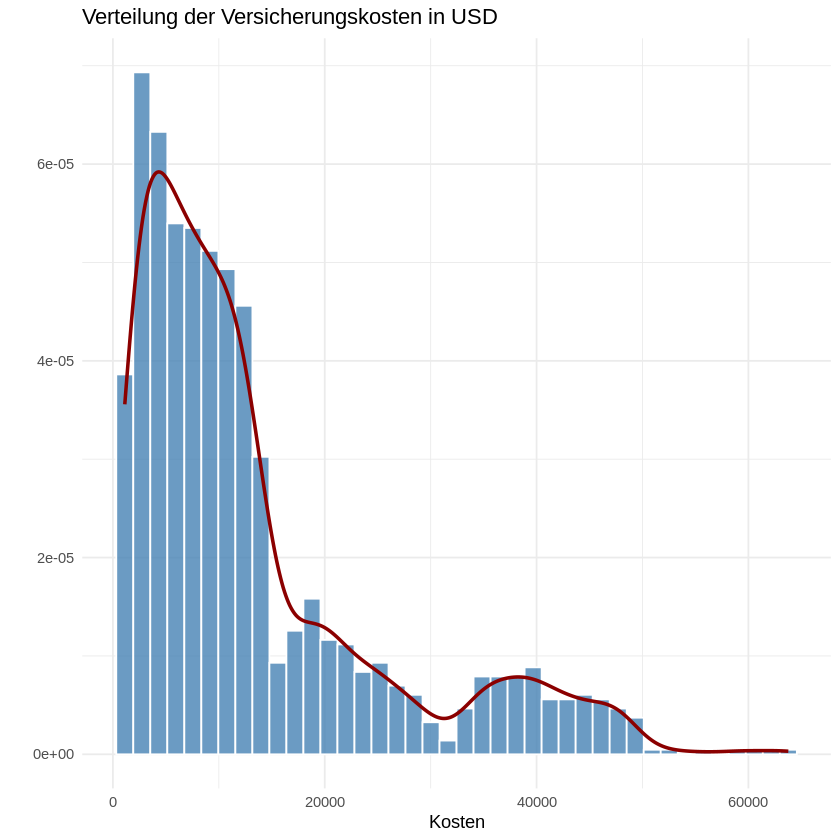

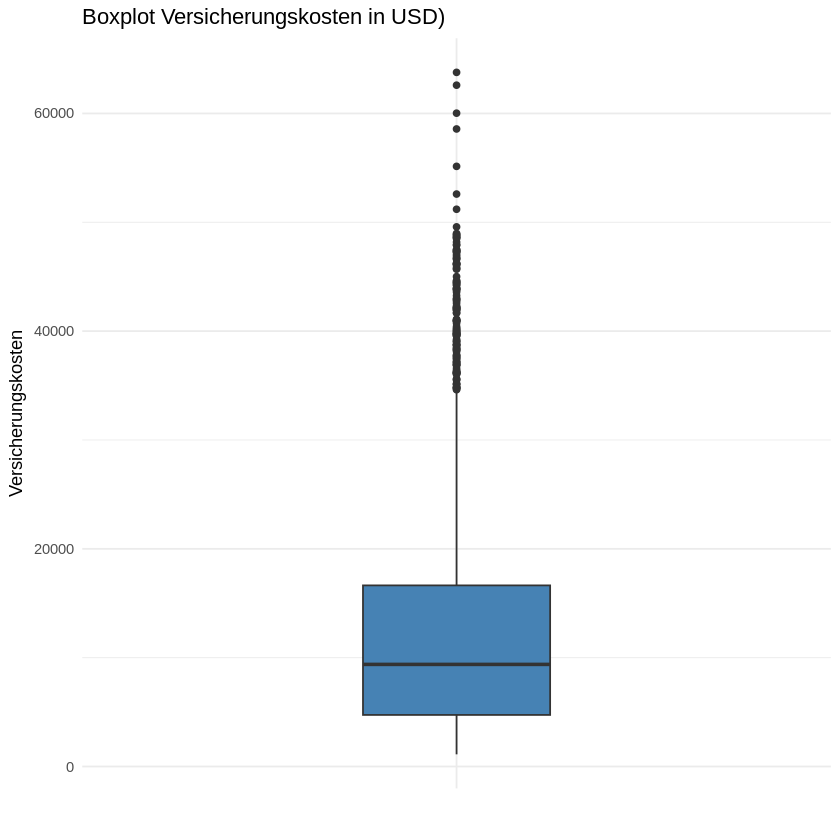

In [28]:

# ============================================
# 1. Versicherungskosten
# ============================================
ggplot(df, aes(x = charges)) +
  geom_histogram(aes(y = after_stat(density)), bins = 40,
                 fill = "steelblue", color = "white", alpha = 0.8) +
  geom_density(color = "darkred", linewidth = 1) +
  labs(
    title = "Verteilung der Versicherungskosten in USD",
    x = "Kosten", y= ""
  ) +
  theme_minimal()


# Ergänzend: Boxplot zeigt Ausreißer kompakt
ggplot(df, aes(x = "", y = charges)) +
  geom_boxplot(fill = "steelblue", width = 0.3) +
  labs(title = "Boxplot Versicherungskosten in USD)", x = "", y = "Versicherungskosten") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


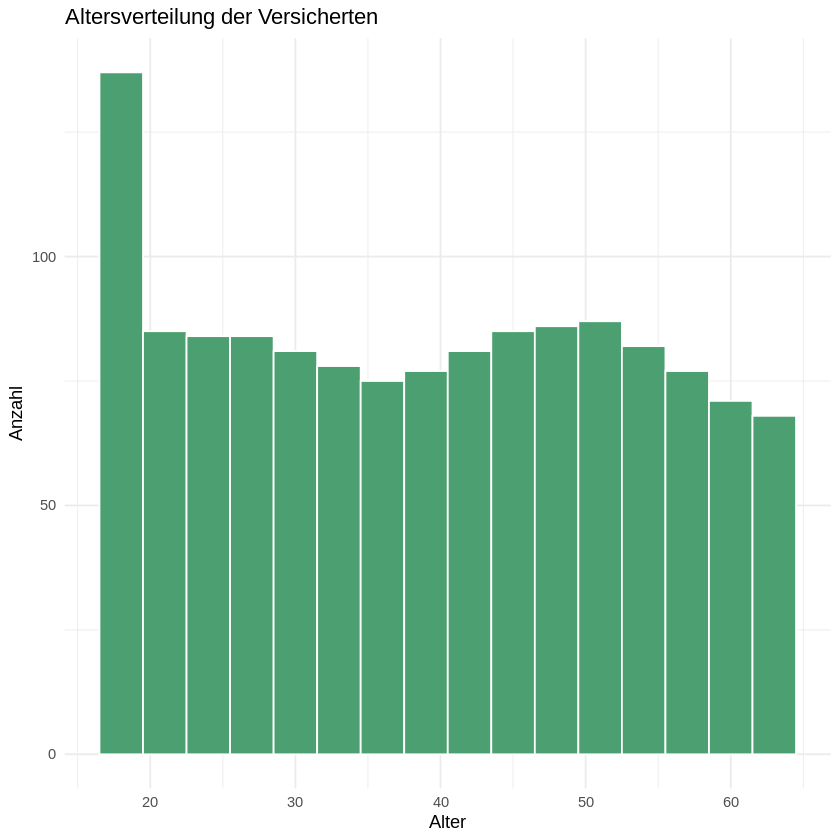

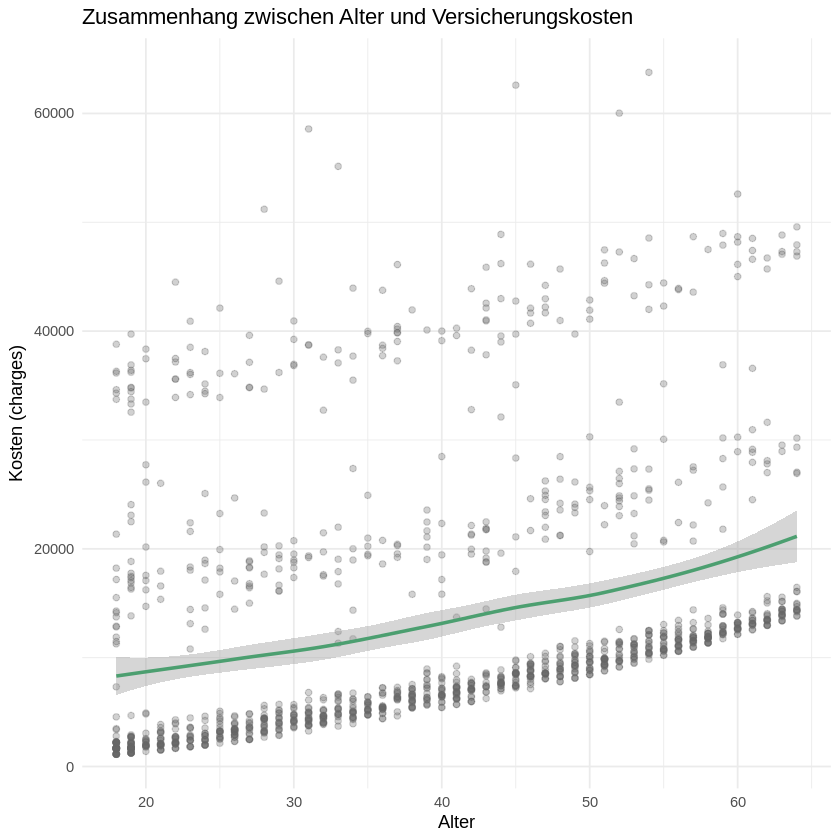

In [29]:
# ============================================
# 2. Alter
# ============================================

# 2a. Nur die Variable -> Histogramm
ggplot(df, aes(x = age)) +
  geom_histogram(binwidth = 3, fill = "#4C9F70", color = "white") +
  labs(title = "Altersverteilung der Versicherten", x = "Alter", y = "Anzahl") +
  theme_minimal()

# 2b. age vs. charges -> Scatterplot mit Trendlinie
ggplot(df, aes(x = age, y = charges)) +
  geom_point(alpha = 0.3, color = "grey40") +
  geom_smooth(method = "loess", color = "#4C9F70", se = TRUE) +
  labs(
    title = "Zusammenhang zwischen Alter und Versicherungskosten in USD",
    x = "Alter", y = "Versicherungskosten"
  ) +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


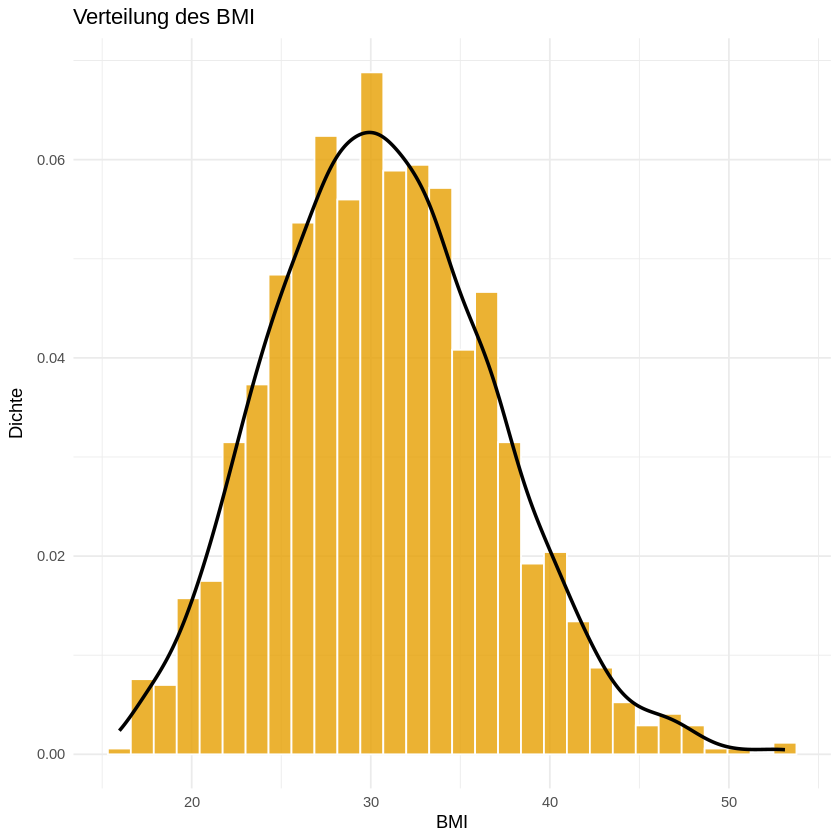

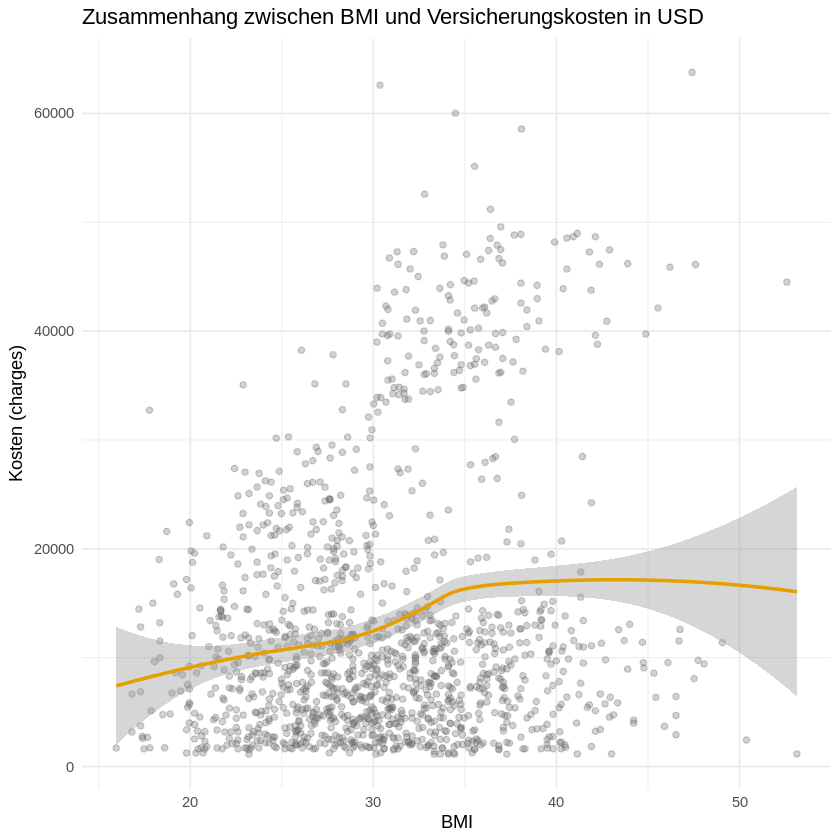

In [31]:
# ============================================
# 3. BMI
# ============================================

# 3a. Nur die Variable -> Histogramm + Density
ggplot(df, aes(x = bmi)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30,
                 fill = "#E69F00", color = "white", alpha = 0.8) +
  geom_density(color = "black", linewidth = 1) +
  labs(title = "Verteilung des BMI", x = "BMI", y = "Dichte") +
  theme_minimal()

# 3b. bmi vs. charges -> Scatterplot mit Trendlinie
ggplot(df, aes(x = bmi, y = charges)) +
  geom_point(alpha = 0.3, color = "grey40") +
  geom_smooth(method = "loess", color = "#E69F00", se = TRUE) +
  labs(
    title = "Zusammenhang zwischen BMI und Versicherungskosten in USD",
    x = "BMI", y = "Kosten (charges)"
  ) +
  theme_minimal()

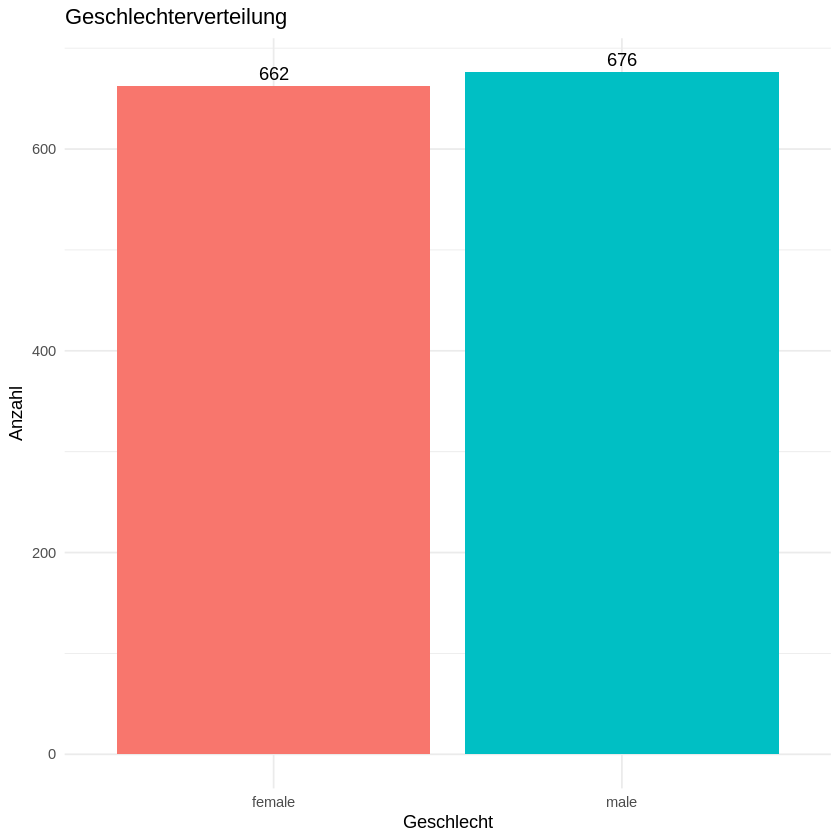

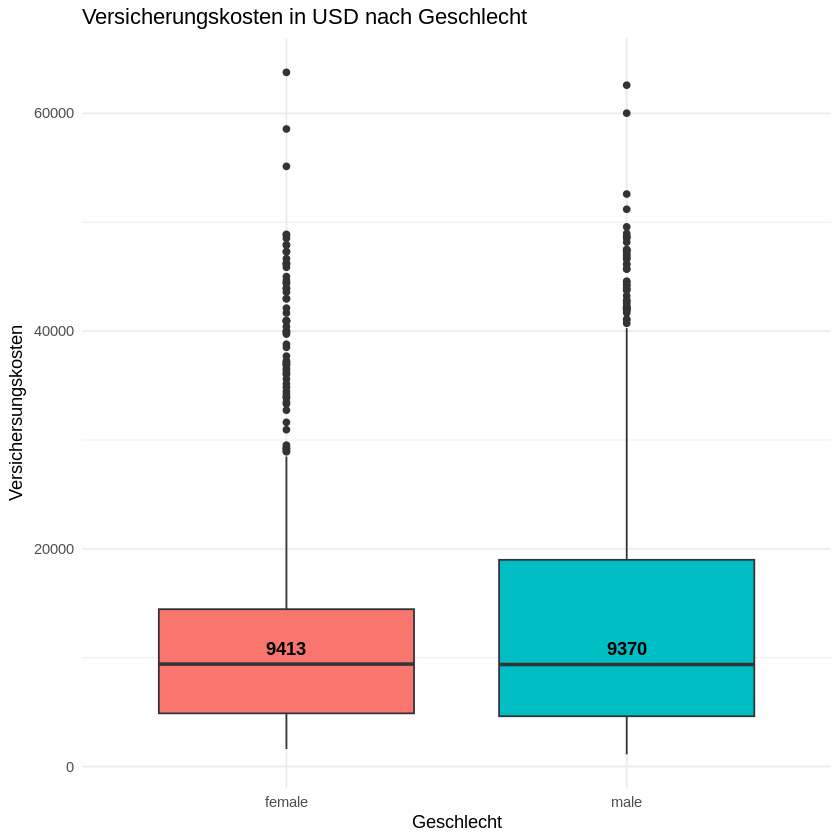

In [42]:
# ============================================
# 4. Geschlecht
# ============================================

# 4a. Nur die Variable -> Balkendiagramm (Counts)
ggplot(df, aes(x = sex, fill = sex)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  labs(title = "Geschlechterverteilung", x = "Geschlecht", y = "Anzahl") +
  theme_minimal() +
  theme(legend.position = "none")

# 4b. sex vs. charges -> Boxplot
ggplot(df, aes(x = sex, y = charges, fill = sex)) +
  geom_boxplot() +
  stat_summary(fun = median, geom = "text",
               aes(label = round(after_stat(y), 0)),
               vjust = -0.7, fontface = "bold") +
  labs(title = "Versicherungskosten in USD nach Geschlecht", x = "Geschlecht", y = "Versichersungskosten") +
  theme_minimal() +
  theme(legend.position = "none")

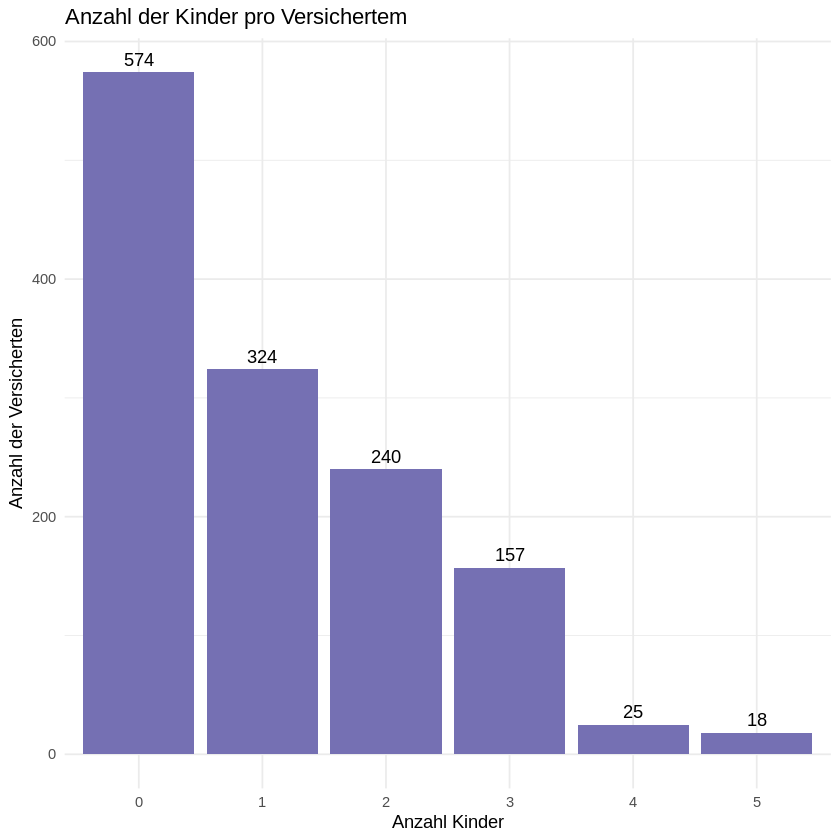

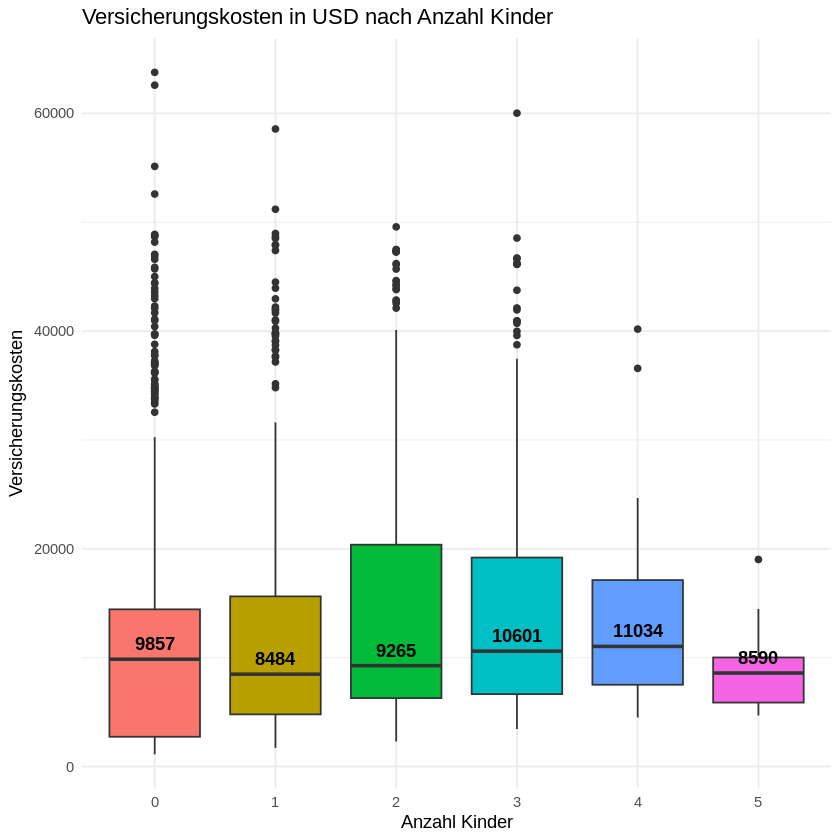

In [43]:
# ============================================
# 5. Kinder
# ============================================

# 5a. Nur die Variable -> Balkendiagramm (Counts)
ggplot(df, aes(x = factor(children))) +
  geom_bar(fill = "#7570B3") +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  labs(title = "Anzahl der Kinder pro Versichertem", x = "Anzahl Kinder", y = "Anzahl der Versicherten") +
  theme_minimal()

# 5b. children vs. charges -> Boxplot
ggplot(df, aes(x = factor(children), y = charges, fill = factor(children))) +
  geom_boxplot() +
  stat_summary(fun = median, geom = "text",
               aes(label = round(after_stat(y), 0)),
               vjust = -0.7, fontface = "bold") +
  labs(title = "Versicherungskosten in USD nach Anzahl Kinder", x = "Anzahl Kinder", y = "Versicherungskosten") +
  theme_minimal() +
  theme(legend.position = "none")

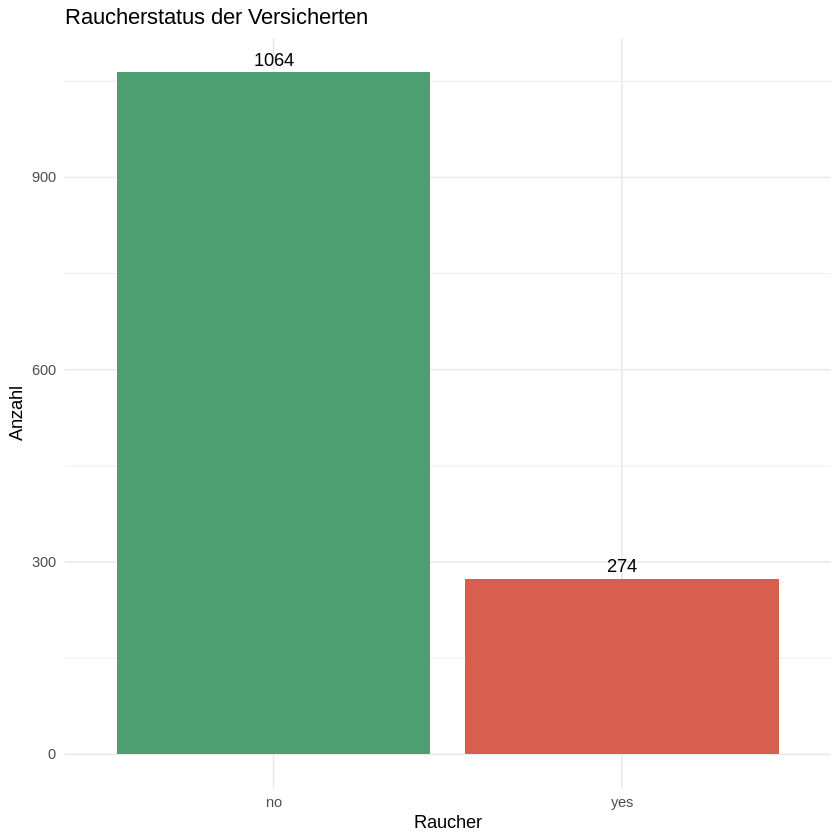

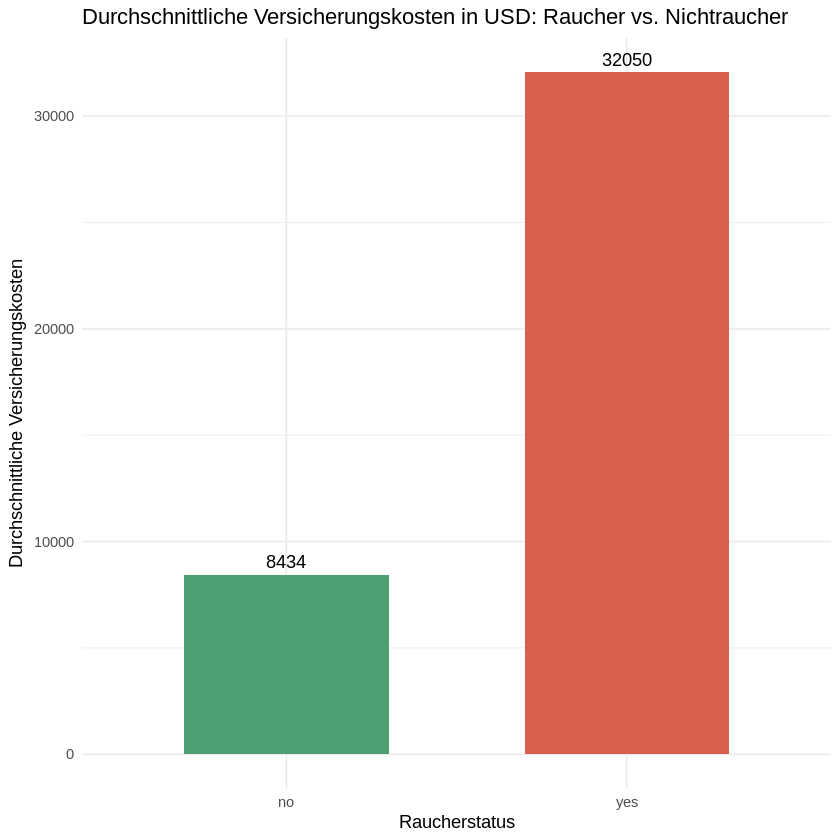

In [48]:
# ============================================
# 6. Raucher
# ============================================

# 6a. Nur die Variable -> Balkendiagramm (Counts)
ggplot(df, aes(x = smoker, fill = smoker)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  labs(title = "Raucherstatus der Versicherten", x = "Raucher", y = "Anzahl") +
  scale_fill_manual(values = c("no" = "#4C9F70", "yes" = "#D6604D")) +
  theme_minimal() +
  theme(legend.position = "none")

# 6b. smoker vs. charges -> Balkendiagramm der Mittelwerte
smoker_summary <- df %>%
  group_by(smoker) %>%
  summarise(mean_charges = mean(charges))

ggplot(smoker_summary, aes(x = smoker, y = mean_charges, fill = smoker)) +
  geom_col(width = 0.6) +
  geom_text(aes(label = round(mean_charges, 0)), vjust = -0.5) +
  labs(
    title = "Durchschnittliche Versicherungskosten in USD: Raucher vs. Nichtraucher",
    x = "Raucherstatus", y = "Durchschnittliche Versicherungskosten"
  ) +
  scale_fill_manual(values = c("no" = "#4C9F70", "yes" = "#D6604D")) +
  theme_minimal() +
  theme(legend.position = "none")


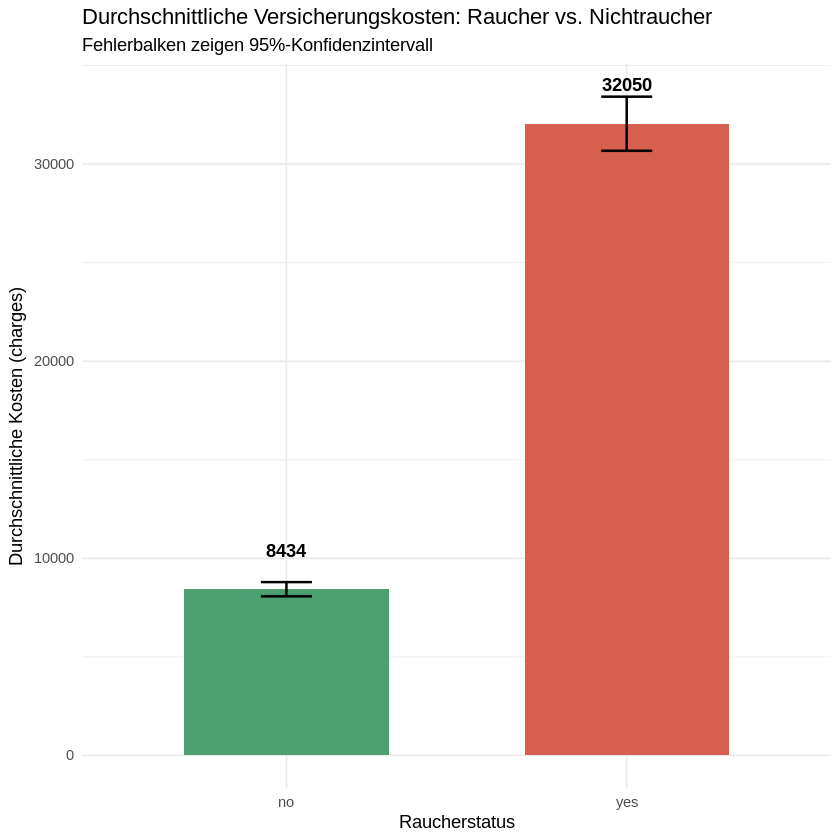

In [52]:
ggplot(df, aes(x = smoker, y = charges, fill = smoker)) +
  stat_summary(fun = mean, geom = "col", width = 0.6) +
  stat_summary(fun.data = mean_cl_normal, geom = "errorbar",
               width = 0.15, color = "black", linewidth = 0.7) +
  stat_summary(fun = mean, geom = "text",
               aes(label = round(after_stat(y), 0)),
               vjust = -2.5, fontface = "bold") +
  labs(
    title = "Durchschnittliche Versicherungskosten: Raucher vs. Nichtraucher",
    subtitle = "Fehlerbalken zeigen 95%-Konfidenzintervall",
    x = "Raucherstatus", y = "Durchschnittliche Kosten (charges)"
  ) +
  scale_fill_manual(values = c("no" = "#4C9F70", "yes" = "#D6604D")) +
  theme_minimal() +
  theme(legend.position = "none")

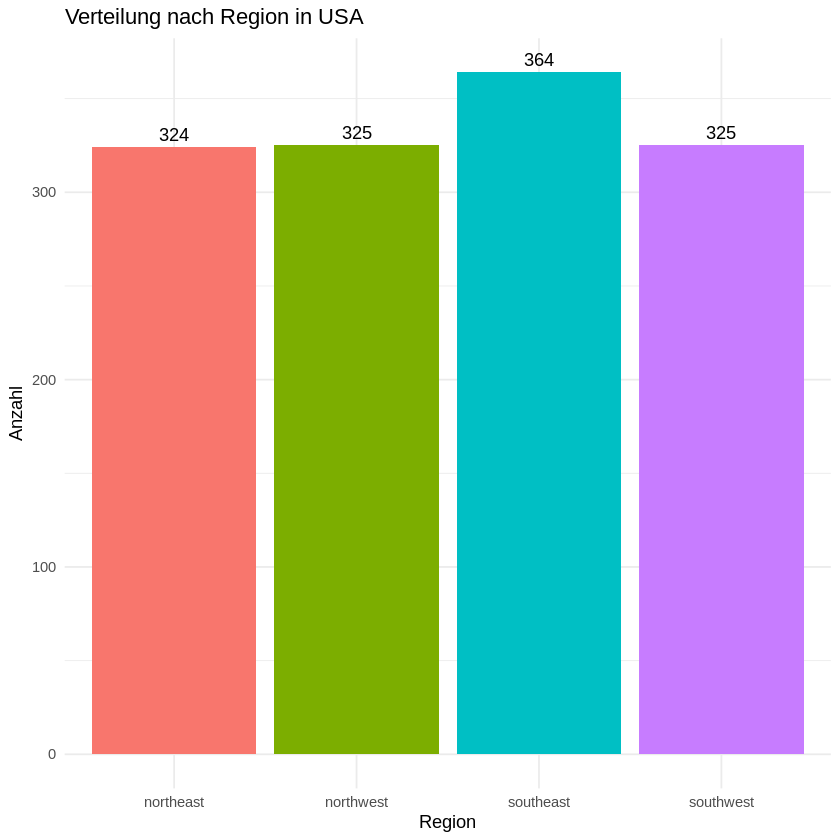

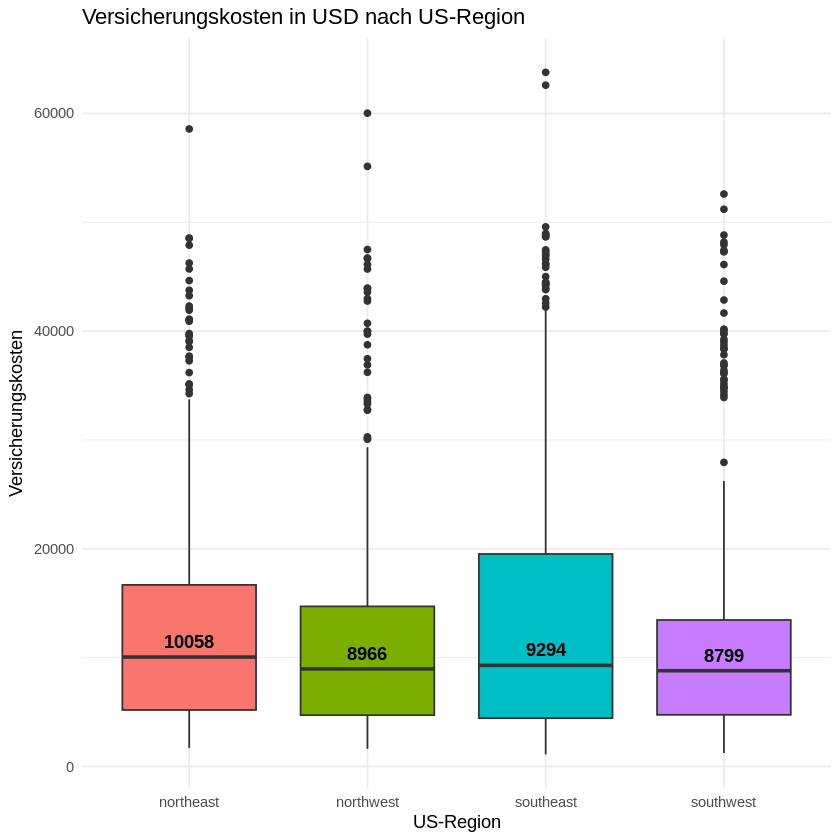

In [49]:
# ============================================
# 7. Region in USA
# ============================================

# 7a. Nur die Variable -> Balkendiagramm (Counts)
ggplot(df, aes(x = region, fill = region)) +
  geom_bar() +
  geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
  labs(title = "Verteilung nach Region in USA", x = "Region", y = "Anzahl") +
  theme_minimal() +
  theme(legend.position = "none")

# 7b. region vs. charges -> Boxplot
ggplot(df, aes(x = region, y = charges, fill = region)) +
  geom_boxplot() +
  stat_summary(fun = median, geom = "text",
               aes(label = round(after_stat(y), 0)),
               vjust = -0.7, fontface = "bold") +
  labs(title = "Versicherungskosten in USD nach US-Region", x = "US-Region", y = "Versicherungskosten") +
  theme_minimal() +
  theme(legend.position = "none")